# Tensor Materials: Uniaxial and Biaxial Crystals

A scalar Optiland material has one complex index n + ik. A crystal has a
permittivity tensor ε instead. `optiland.materials.anisotropic` builds the
tensors of uniaxial and biaxial crystals from the scalar materials of the
catalog, turns them into the global frame, and returns ε, μ, ξ and ζ as
(N, 3, 3) arrays at N wavelengths in µm, on the NumPy and the Torch backend.

This example builds calcite and KTP, checks the tensors against their
closed forms, and plots the birefringence of calcite over the visible.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.materials import (
    BiaxialMaterial,
    Material,
    UniaxialMaterial,
    euler_zxz_matrix,
)

## Calcite, a uniaxial crystal

A uniaxial material takes the material of the ordinary index, the material
of the extraordinary index and the optic axis ĉ in the global frame:
ε = n_o² I + (n_e² − n_o²) ĉĉᵀ. Here the optic axis lies at 45° in the x–z
plane, the cut of a beam displacer.

In [2]:
n_o = Material("CaCO3", reference="Ghosh-o")
n_e = Material("CaCO3", reference="Ghosh-e")
calcite = UniaxialMaterial(n_o, n_e, optic_axis=(1.0, 0.0, 1.0))

wavelength = 0.5893  # µm
eps = calcite.epsilon(wavelength)[0]
print("epsilon (global frame):")
print(np.round(eps.real, 6))

no = float(np.ravel(n_o.n(wavelength))[0])
ne = float(np.ravel(n_e.n(wavelength))[0])
c = np.array([1.0, 0.0, 1.0]) / np.sqrt(2.0)
closed_form = no**2 * np.eye(3) + (ne**2 - no**2) * np.outer(c, c)
print(f"n_o = {no:.6f}, n_e = {ne:.6f}")
print(f"max |epsilon - closed form| = {np.max(np.abs(eps - closed_form)):.1e}")

epsilon (global frame):
[[ 2.479343  0.       -0.27076 ]
 [ 0.        2.750103  0.      ]
 [-0.27076   0.        2.479343]]
n_o = 1.658343, n_e = 1.486130
max |epsilon - closed form| = 0.0e+00


The optic axis is an eigenvector of ε with the eigenvalue n_e²; every vector
normal to it has the eigenvalue n_o². A lossless crystal has a Hermitian
6 × 6 constitutive matrix, and a crystal without optical activity is
reciprocal (ε = εᵀ).

In [3]:
values, vectors = np.linalg.eigh(eps.real)
print("principal indices:", np.round(np.sqrt(values), 6))
print("transparent:", calcite.is_transparent(wavelength))
print("reciprocal:", calcite.is_reciprocal(wavelength))
print("isotropic:", calcite.is_isotropic(wavelength))

principal indices: [1.48613  1.658343 1.658343]
transparent: True
reciprocal: True
isotropic: False


A tensor material has no single refractive index, so `n` and `k` raise an
error instead of returning a number that a scalar trace would use silently.

In [4]:
try:
    calcite.n(wavelength)
except TypeError as error:
    print("TypeError:", error)

TypeError: UniaxialMaterial is a tensor material and has no single refractive index; use epsilon() or constitutive_6x6().


## Birefringence over the visible

The tensors take an array of wavelengths.

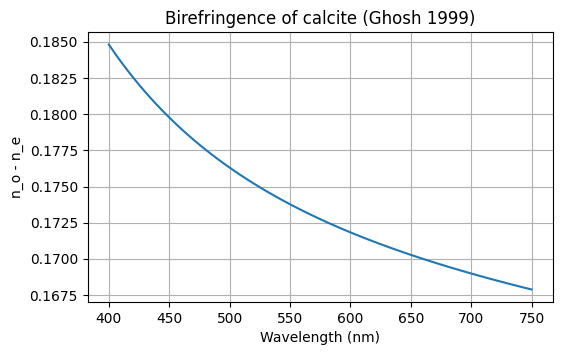

In [5]:
wavelengths = np.linspace(0.40, 0.75, 71)
eps_z = UniaxialMaterial(n_o, n_e).epsilon(wavelengths)  # optic axis along z
n_ordinary = np.sqrt(eps_z[:, 0, 0].real)
n_extraordinary = np.sqrt(eps_z[:, 2, 2].real)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(wavelengths * 1e3, n_ordinary - n_extraordinary)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("n_o - n_e")
ax.set_title("Birefringence of calcite (Ghosh 1999)")
ax.grid(True)
plt.show()

## KTP, a biaxial crystal

A biaxial material takes three principal materials along the crystal axes
and a crystal-to-global rotation R, ε = R diag(n_x², n_y², n_z²) Rᵀ.
`euler_zxz_matrix(φ, θ, ψ)` gives R = Rz(φ) Rx(θ) Rz(ψ) (angles in degrees).
The two optic axes (binormals) lie in the crystal x–z plane at ±V from z,
with tan V = (n_z / n_x) √((n_y² − n_x²) / (n_z² − n_y²)).

In [6]:
ktp = BiaxialMaterial(
    Material("KTiOPO4", reference="Kato-alpha"),
    Material("KTiOPO4", reference="Kato-beta"),
    Material("KTiOPO4", reference="Kato-gamma"),
    rotation=euler_zxz_matrix(0.0, 30.0, 0.0),
)
nx, ny, nz = (
    float(np.ravel(Material("KTiOPO4", reference=f"Kato-{name}").n(wavelength))[0])
    for name in ("alpha", "beta", "gamma")
)
V = np.degrees(np.arctan(nz / nx * np.sqrt((ny**2 - nx**2) / (nz**2 - ny**2))))
print(f"n_x, n_y, n_z = {nx:.6f}, {ny:.6f}, {nz:.6f};  V = {V:.3f} deg")

eps_ktp = ktp.epsilon(wavelength)[0].real
principal = np.sqrt(np.linalg.eigvalsh(eps_ktp))
print("principal indices from the tensor:", np.round(principal, 6))


def mode_indices(eps, s):
    """The two indices of plane waves along the unit wave normal s.

    1/n² are the eigenvalues of ε⁻¹ restricted to the plane normal to s
    (the index ellipsoid of D).
    """
    s = s / np.linalg.norm(s)
    a = np.cross(s, [1.0, 0.0, 0.0] if abs(s[0]) < 0.9 else [0.0, 1.0, 0.0])
    a /= np.linalg.norm(a)
    b = np.cross(s, a)
    basis = np.stack([a, b], axis=1)
    inverse = basis.T @ np.linalg.inv(eps) @ basis
    return np.sort(1.0 / np.sqrt(np.linalg.eigvalsh(inverse)))


R = euler_zxz_matrix(0.0, 30.0, 0.0)
binormal = R @ np.array([np.sin(np.radians(V)), 0.0, np.cos(np.radians(V))])
print("binormal in the global frame:", np.round(binormal, 6))
print("mode indices along the binormal:", np.round(mode_indices(eps_ktp, binormal), 9))
print(
    "mode indices along global z:   ",
    np.round(mode_indices(eps_ktp, np.array([0.0, 0.0, 1.0])), 9),
)

n_x, n_y, n_z = 1.767741, 1.777546, 1.873367;  V = 18.472 deg
principal indices from the tensor: [1.767741 1.777546 1.873367]
binormal in the global frame: [ 0.316844 -0.474239  0.821406]
mode indices along the binormal: [1.77754556 1.77754556]
mode indices along global z:    [1.7677407  1.80011705]
